# Week 14 - Statistical Estimators

## 1 - Statistics and Statistical Estimators

A **statistic**, t = T(y), is any function of data which doesn't depend on any unknown parameter values. This means we can form almost any equation we like using any data points, the size of the dataset, and any numbers and operations, but we can't introduce other variables that we do not know. Most of you will be familiar with some of the common statistics that we use:
- Sample Mean $\bar{x} = \frac{1}{N}\sum^N_{i=1} x_i$
- Sample Standard Deviation $\sigma = \sqrt{\frac{\sum^N_{i=1}(x_i-\bar{x})^2)}{N}}$
- Sample Maximum $\max_{i=1,2,\cdots,n}y_i$
- Maximum Likelihood Estimator

Most often in wind energy settings we are interested in using statistics as **estimators** for some unknown parameter. Parameters of interest are often denoted as $\theta$, with the estimator written as $\hat{\theta}$. An estimator is a statistic that is used to estimate an unknown population parameter based on sample data. For example, we often wish to approximate the mean wind speed in an area. We are never going to know the exact true value for this (i.e. the population mean) but we can guess it fairly accurately using the sample mean. In this case the **sample mean** is an **estimator** for the population mean. The value of the estimator evaluated at the observed data is referred to as the **estimate**. Note: Since an estimator is a statistic, it follows the rule that it cannot depend on any unknown parameter values.

Sample mean tends to be the most common, and perhaps most intuitive, choice of estimator for population mean. If I proposed that instead we chose just the first data point in the set, $x_1$, as our estimator you likely instinctively think that this estimator is worse. Would you be able to justify why?


#### Exercise 1.1
Why do you think $x_1$ a worse estimator than sample mean?

More significantly, do you think that sample mean is the *best* estimator for population mean? Can you explain why or why not?
#### Exercise 1.2
Please write your answer below.

For almost every unknown parameter we will have many possible estimators available - and with some parameters there will be no natural or obvious statistic to estimate them. Luckily, we have many considerations (and tools to assess them!) which allow us to choose the best estimator for each scenario.

## 2 - Unbiasedness, Consistency and Efficiency
When working with estimators we generally want to look at three key properties:
- Unbiasedness
- Consistency
- Efficiency

Things are going to get a little bit technical and mathematical for the rest of this session - remember I will be around on Wednesday to help you work through these.
### 2.1 - Unbiased estimators
An estimator is said to be **unbiased** if the **expected value** of the estimator is equivalent to the true value of the parameter across all, i.e.
$$\mathbb{E}(\hat{\theta})=\theta.$$

The expected value is the anticipated long-term probability-weighted average of a random variable,
for a discrete random variable that is 
$$\mathbb{E}(y) = \sum^N_{i=1} y_i P(Y=y_i),$$ 
and for a continuous random variable
$$\mathbb{E}(y) = \sum^N_{i=1} y_i f(y_i).$$ 
Don't worry if you don't follow the formalae - the idea is that it is the sum of every possible value weighted by how likely it is to appear. It's often thought of as the 'centre of mass' of all possible probabilities.

By extension, a *biased estimator* is an estimator whose expected value is not equivalent to the population parameter,
$$\mathbb{\hat{\theta}}\neq \theta,$$ and we define the estimator **bias** as 
$$bias(\hat{\theta})=\mathbb{\hat{\theta}}-\theta\neq0.$$
Where we do not have an unbiased estimator, we aim to select one with the lowest possible bias whilst balancing the other considerations. In some cases we would choose a biased estimator which met other criteria better. For example, an estimator slightly biased with a very small variance is more likely to be either higher or lower (depending on direction of bias) than the population parameter, but will also be likely to be very close to the true value. Conversely, an unbiased estimator with a high bias is equally likely to lie on either side of the parameter, but is more likely to be very far from the true parameter. Let's demonstrate this using some of the Python plotting and package techniques we have learned.

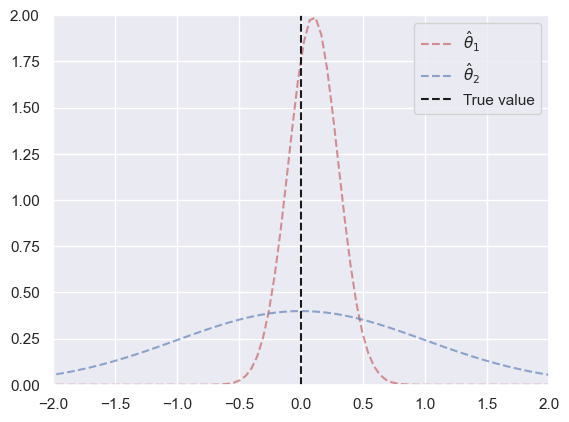

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
sns.set_theme()
fig, ax = plt.subplots(1, 1)
x = np.linspace(norm.ppf(0.01),
                norm.ppf(0.99), 100)
ax.plot(x, norm.pdf(x,0.1,0.2),'r--', alpha=0.6, label=r'$\hat{\theta}_1$')
ax.plot(x, norm.pdf(x,0,1),'b--', alpha=0.6, label=r'$\hat{\theta}_2$')
ax.plot([0,0],[0,2], 'k--', label='True value')
plt.xlim(-2,2)
plt.ylim(0,2)
plt.legend()

## 2.2 - Consistency

The **consistency** of an estimator is the idea that as our dataset sample size increases, our estimator should become more concentrated around the true value. Specifically, an estimator is **unbiased** if for any $\epsilon>0$
$$\mathbb{P}(|\hat{\theta}-\theta|>\epsilon)\rightarrow 0, N\rightarrow \infty.$$
For engineers, this format of equation may well look familiar from calculus modules but we'll break it down step by step. This equation is saying that as the data sample size $N$ approaches infinity (i.e. as it gets larger), that the bias, $\hat{\theta}-\theta$ approaches 0. This is functionally saying that as our sample size increases we expect the estimate to get closer to the parameter value. This can be very difficult to assess, but we have an easier equivalent condition: If $Var(\hat{\theta})\rightarrow 0$ and $bias(\hat{\theta})\rightarrow 0$, then $\hat{\theta}$ is consistent.
The reason this works is that the mean-squared-error of the estimator, 
$$MSE(\hat{\theta})=\mathbb{E}[\hat(\theta)-\theta)^2]=Var(\hat{\theta})+bias(\hat{\theta})^2.$$
This equation tells us two things. Firstly, MSE is the square of $|\hat{\theta}-\theta|$ and therefore MSE approaching 0 is equivalent to the estimator approaching the population parameter. Secondly, it tells us that MSE is equivalent to the variance plus the square of the bias. We can infer from these two points that if variance and bias both approach 0, MSE approaches 0 and thus the estimator approaches the population parameter. Importantly, for unbiased estimators we now only have a single consideration: does the variance approach 0 as we increase our population size?

Let's revisit two of our unbiased estimators, $x_1$ and $\bar{x}$ which have variances $\sigma^2$ (population variance) and $\frac{\sigma^2}{n}$ , respectively. As we increase the sample size which of these two variances will change?
#### Exercise 2.2.1 
Which of the two unbiased estimators is also consistent?

Note: a key takeaway from above is that mean-squared error is a very important measure of estimator quality balancing both bias and variance. An estimator with the lowest MSE is likely to be a sensible option.

## 2.3 - Efficiency
The **efficiency** of an estimator is the ratio of estimator variance to the minimum possible variance amongst all unbiased estimators,
$$eff(\hat{\theta})=\frac{Var(\hat{\theta})}{\min_{\tilde{\theta}\in\hat{\Theta_0}}\tilde{\theta}},$$
where $\Theta_0$ is the set of all possible unbiased estimators. We then say that an estimator is **efficient** if its efficiency is 1, that is if it is the unbiased estimator with the *lowest possible variance*. We sometimes refer to these as **Minimum Variance Unbiased Estimators (MVUE)**. This condition is rarely met, so we are generally looking for **asymptotic efficiency**, with efficiency approaching 1 as sample size approaches infinity.

## 3 - The Maximum Likelihood Estimator (MLE)
Where there is no obvious or natural estimator for a parameter, the best place to start is with the **Maximum Likelihood Estimator (MLE)**. This was covered in more depth in [Week 4](https://github.com/kaiyaraby/wind_energy_analytics_ke/tree/main/Statistics/Week%204) on Distribution fitting. The MLE is the function of data which *maximises the likelihood* of the estimate being the true parameter given the observed data. The MLE is
- asymptotically unbiased
- asymptotically consistent
- asymptotically efficient.